## 1. Import Necessary Libraries

In [3]:
# ! pip install pillow tensorflow keras matplotlib numpy split-folders
import zipfile
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import splitfolders

## 2. Unzip the dataset

In [4]:
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/raw_data')

## 3. Process & Crop Images

In [5]:
def process_and_crop_images(input_folder, output_folder, target_size=(150, 150)):
    for category in ['NORMAL', 'PNEUMONIA']:
        category_path = os.path.join(input_folder, category)
        save_path = os.path.join(output_folder, category)
        os.makedirs(save_path, exist_ok=True)

        for filename in os.listdir(category_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(category_path, filename)
                    img = Image.open(img_path).convert('RGB')
                    w, h = img.size
                    min_dim = min(w, h)
                    img = img.crop(((w - min_dim) // 2, (h - min_dim) // 2,
                                    (w + min_dim) // 2, (h + min_dim) // 2))
                    img = img.resize(target_size)
                    img.save(os.path.join(save_path, filename))
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

# Set paths
original_data_path = '/content/raw_data'
cropped_data_path = '/content/Processed_Data'

# Run image processing
process_and_crop_images(original_data_path, cropped_data_path)

## 4. Split folders into train, val, test

In [6]:
splitfolders.ratio(cropped_data_path, output="/content/Final_Data", seed=42, ratio=(.8, .1, .1))

Copying files: 2000 files [00:00, 8795.49 files/s]


In [25]:
import shutil
from google.colab import files

shutil.make_archive('/content/Processed_Data', 'zip', '/content/Processed_Data')

files.download('/content/Processed_Data.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. ImageDataGenerators

In [7]:
train_dir = '/content/Final_Data/train'
val_dir = '/content/Final_Data/val'
test_dir = '/content/Final_Data/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
val_generator = val_test_datagen.flow_from_directory(val_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
test_generator = val_test_datagen.flow_from_directory(test_dir, target_size=(150, 150), batch_size=32, class_mode='binary', shuffle=False)

Found 1600 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


## 6. Define model

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train model

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_pneumonia_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(train_generator, epochs=20, validation_data=val_generator, callbacks=callbacks)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5002 - loss: 0.8827

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.5014 - loss: 0.8797 - val_accuracy: 0.5650 - val_loss: 0.9151
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7179 - loss: 0.5678

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.7188 - loss: 0.5666 - val_accuracy: 0.8500 - val_loss: 0.4088
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8075 - loss: 0.4551

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.8078 - loss: 0.4544 - val_accuracy: 0.8650 - val_loss: 0.3239
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8544 - loss: 0.3644

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.9085 - loss: 0.2469 - val_accuracy: 0.9200 - val_loss: 0.2158
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8681 - loss: 0.3002

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.8684 - loss: 0.3001 - val_accuracy: 0.9300 - val_loss: 0.2141
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8901 - loss: 0.2953

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.8903 - loss: 0.2949 - val_accuracy: 0.9300 - val_loss: 0.1882
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8936 - loss: 0.2625 - val_accuracy: 0.8550 - val_loss: 0.3132
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9078 - loss: 0.2585

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.9078 - loss: 0.2585 - val_accuracy: 0.9300 - val_loss: 0.1849
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.8913 - loss: 0.2503 - val_accuracy: 0.9300 - val_loss: 0.2213
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8996 - loss: 0.2516

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8999 - loss: 0.2513 - val_accuracy: 0.9450 - val_loss: 0.1759
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.9154 - loss: 0.2175 - val_accuracy: 0.8950 - val_loss: 0.2324
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8905 - loss: 0.2737 - val_accuracy: 0.9400 - val_loss: 0.2111
Epoch 16/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.9072 - loss: 0.2467 - val_accuracy: 0.9250 - val_loss: 0.1966
Epoch 17/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.9167 - loss: 0.2455 - val_accuracy: 0.9200 - val_loss: 0.2408
Epoch 18/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.9207 - loss: 0.2183 - val_accuracy: 0.9350 - val_loss: 0.2124


## 8. Evaluate on test set

In [12]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9487 - loss: 0.1297
Test Accuracy: 91.00%


## 9. Accuracy & Loss Charts

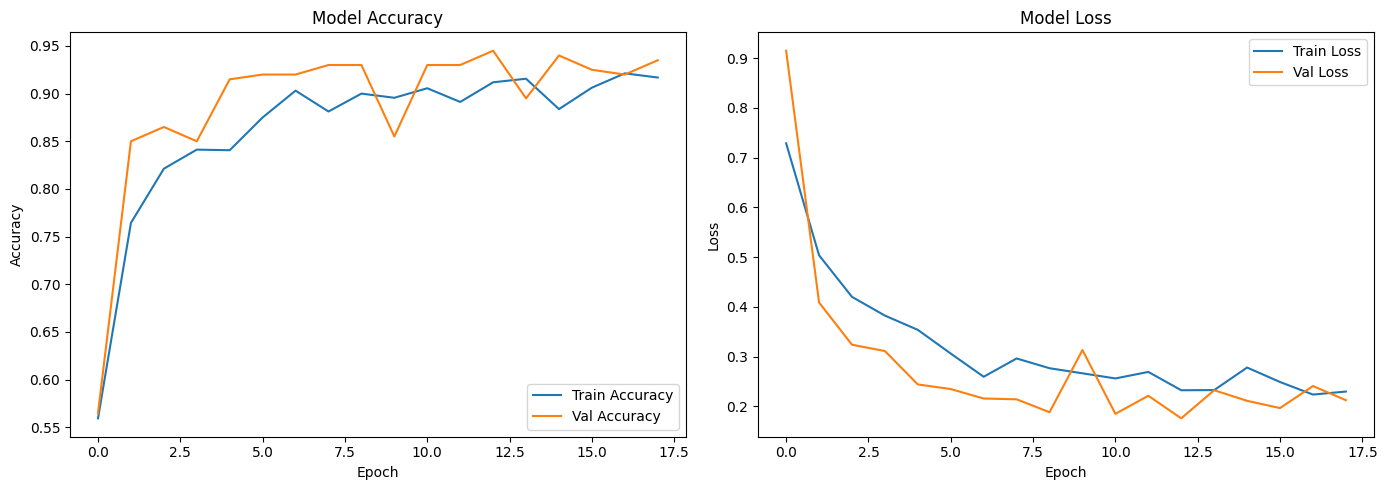

In [13]:
# Plot Accuracy and Loss
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 10. Classify Image (Normal or Pneumonia)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


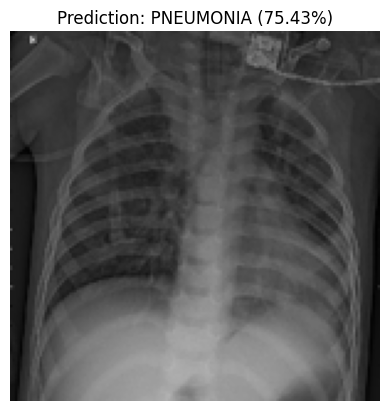

In [24]:
def classify_local_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')

        # Preprocess
        w, h = img.size
        min_dim = min(w, h)
        img = img.crop(((w - min_dim) // 2, (h - min_dim) // 2,
                        (w + min_dim) // 2, (h + min_dim) // 2))
        img = img.resize((150, 150))
        img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

        prediction = model.predict(img_array)[0][0]
        label = 'PNEUMONIA' if prediction > 0.5 else 'NORMAL'
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Prediction: {label} ({confidence*100:.2f}%)')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

classify_local_image('/content/Processed_Data/PNEUMONIA/PNEUMONIA_150.png')
